<a href="https://colab.research.google.com/github/Ty700/STAT_650/blob/main/Tyler_Scotti_Midterm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# STAT 650 – Midterm Report
## Analyzing Customer and Restaurant Data to Recommend Restaurants

---

## 1. Introduction

This report analyzes a restaurant recommendation dataset containing information about restaurants (location, cuisine, price, hours, parking, accepted payments) and consumers (demographics, cuisine preferences, payment methods) along with user–restaurant ratings.

**Objective:** Merge, clean, and explore these datasets to uncover insights about restaurant trends and user behavior, and ultimately recommend a restaurant for a new user profile (student, single, medium budget, prefers public transport).

**Approach:**
1. Load and inspect all 9 CSV files
2. Merge them into a single master DataFrame using appropriate join keys
3. Clean and standardize the merged data
4. Perform exploratory data analysis (EDA) with visualizations
5. Generate hypotheses based on findings
6. Provide a data-driven restaurant recommendation


---
## 2. Data Preparation

### 2.1 Loading the Data


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

# Load Data
geoplaces = pd.read_csv('geoplaces2.csv', encoding='latin-1')
chefmoz_accepts = pd.read_csv('chefmozaccepts.csv')
chefmoz_cuisine = pd.read_csv('chefmozcuisine.csv')
chefmoz_hours = pd.read_csv('chefmozhours4.csv')
chefmoz_parking = pd.read_csv('chefmozparking.csv')
user_cuisine = pd.read_csv('usercuisine.csv')
user_payment = pd.read_csv('userpayment.csv')
user_profile = pd.read_csv('userprofile.csv')
ratings = pd.read_csv('rating_final.csv')

print("Datasets loaded successfully!")
print(f"  geoplaces2:       {geoplaces.shape}")
print(f"  chefmozaccepts:   {chefmoz_accepts.shape}")
print(f"  chefmozcuisine:   {chefmoz_cuisine.shape}")
print(f"  chefmozhours4:    {chefmoz_hours.shape}")
print(f"  chefmozparking:   {chefmoz_parking.shape}")
print(f"  usercuisine:      {user_cuisine.shape}")
print(f"  userpayment:      {user_payment.shape}")
print(f"  userprofile:      {user_profile.shape}")
print(f"  rating_final:     {ratings.shape}")


Datasets loaded successfully!
  geoplaces2:       (130, 21)
  chefmozaccepts:   (1314, 2)
  chefmozcuisine:   (916, 2)
  chefmozhours4:    (2339, 3)
  chefmozparking:   (702, 2)
  usercuisine:      (330, 2)
  userpayment:      (177, 2)
  userprofile:      (138, 19)
  rating_final:     (1161, 5)


### 2.2 Inspecting Each DataFrame

We check for missing values, data types, and inconsistencies in each dataset.


In [3]:
datasets = {
    'geoplaces2': geoplaces,
    'chefmozaccepts': chefmoz_accepts,
    'chefmozcuisine': chefmoz_cuisine,
    'chefmozhours4': chefmoz_hours,
    'chefmozparking': chefmoz_parking,
    'usercuisine': user_cuisine,
    'userpayment': user_payment,
    'userprofile': user_profile,
    'rating_final': ratings
}

for name, df in datasets.items():
    print(f"\n{'='*60}")
    print(f"  {name}  —  shape: {df.shape}")
    print(f"{'='*60}")
    print(f"Columns: {list(df.columns)}")
    print(f"\nData types:\n{df.dtypes}")
    missing = df.isnull().sum()
    if missing.sum() > 0:
        print(f"\nMissing values:\n{missing[missing > 0]}")
    else:
        print("\nNo missing values.")
    print(f"\nFirst 2 rows:")
    display(df.head(2))



  geoplaces2  —  shape: (130, 21)
Columns: ['placeID', 'latitude', 'longitude', 'the_geom_meter', 'name', 'address', 'city', 'state', 'country', 'fax', 'zip', 'alcohol', 'smoking_area', 'dress_code', 'accessibility', 'price', 'url', 'Rambience', 'franchise', 'area', 'other_services']

Data types:
placeID             int64
latitude          float64
longitude         float64
the_geom_meter     object
name               object
address            object
city               object
state              object
country            object
fax                object
zip                object
alcohol            object
smoking_area       object
dress_code         object
accessibility      object
price              object
url                object
Rambience          object
franchise          object
area               object
other_services     object
dtype: object

No missing values.

First 2 rows:


,placeID,latitude,longitude,the_geom_meter,name,address,city,state,country,fax,...,alcohol,smoking_area,dress_code,accessibility,price,url,Rambience,franchise,area,other_services
0,134999,18.915421,-99.184871,0101000020957F000088568DE356715AC138C0A525FC46...,Kiku Cuernavaca,Revolucion,Cuernavaca,Morelos,Mexico,?,...,No_Alcohol_Served,none,informal,no_accessibility,medium,kikucuernavaca.com.mx,familiar,f,closed,none
1,132825,22.147392,-100.983092,0101000020957F00001AD016568C4858C1243261274BA5...,puesto de tacos,esquina santos degollado y leon guzman,s.l.p.,s.l.p.,mexico,?,...,No_Alcohol_Served,none,informal,completely,low,?,familiar,f,open,none



  chefmozaccepts  —  shape: (1314, 2)
Columns: ['placeID', 'Rpayment']

Data types:
placeID      int64
Rpayment    object
dtype: object

No missing values.

First 2 rows:


,placeID,Rpayment
0,135110,cash
1,135110,VISA



  chefmozcuisine  —  shape: (916, 2)
Columns: ['placeID', 'Rcuisine']

Data types:
placeID      int64
Rcuisine    object
dtype: object

No missing values.

First 2 rows:


...

,userID,Upayment
0,U1001,cash
1,U1002,cash



  userprofile  —  shape: (138, 19)
Columns: ['userID', 'latitude', 'longitude', 'smoker', 'drink_level', 'dress_preference', 'ambience', 'transport', 'marital_status', 'hijos', 'birth_year', 'interest', 'personality', 'religion', 'activity', 'color', 'weight', 'budget', 'height']

Data types:
userID               object
latitude            float64
longitude           float64
smoker               object
drink_level          object
dress_preference     object
ambience             object
transport            object
marital_status       object
hijos                object
birth_year            int64
interest             object
personality          object
religion             object
activity             object
color                object
weight                int64
budget               object
height              float64
dtype: object

No missing values.

First 2 rows:


,userID,latitude,longitude,smoker,drink_level,dress_preference,ambience,transport,marital_status,hijos,birth_year,interest,personality,religion,activity,color,weight,budget,height
0,U1001,22.139997,-100.978803,false,abstemious,informal,family,on foot,single,independent,1989,variety,thrifty-protector,none,student,black,69,medium,1.77
1,U1002,22.150087,-100.983325,false,abstemious,informal,family,public,single,independent,1990,technology,hunter-ostentatious,Catholic,student,red,40,low,1.87



  rating_final  —  shape: (1161, 5)
Columns: ['userID', 'placeID', 'rating', 'food_rating', 'service_rating']

Data types:
userID            object
placeID            int64
rating             int64
food_rating        int64
service_rating     int64
dtype: object

No missing values.

First 2 rows:


,userID,placeID,rating,food_rating,service_rating
0,U1077,135085,2,2,2
1,U1077,135038,2,2,1


In [4]:
print("Checking for '?' placeholders in geoplaces2:")
for col in geoplaces.columns:
    q_count = (geoplaces[col] == '?').sum()
    if q_count > 0:
        print(f"  {col}: {q_count} '?' values")

print("\nChecking for '?' placeholders in userprofile:")
for col in user_profile.columns:
    q_count = (user_profile[col] == '?').sum()
    if q_count > 0:
        print(f"  {col}: {q_count} '?' values")


Checking for '?' placeholders in geoplaces2:
  address: 27 '?' values
  city: 18 '?' values
  state: 18 '?' values
  country: 28 '?' values
  fax: 130 '?' values
  zip: 74 '?' values
  url: 116 '?' values

Checking for '?' placeholders in userprofile:
  smoker: 3 '?' values
  dress_preference: 5 '?' values
  ambience: 6 '?' values
  transport: 7 '?' values
  marital_status: 4 '?' values
  hijos: 11 '?' values
  activity: 7 '?' values
  budget: 7 '?' values


### 2.3 Merging Strategy

1. **Start with `rating_final`** as the base with  each row represents one user–restaurant rating.
2. **Left join `userprofile`** on `userID` attach user demographics to each rating.
3. **Left join `geoplaces2`** on `placeID` attach restaurant details to each rating.
4. **Left join aggregated restaurant data**  on `placeID`.
5. **Left join aggregated user preference data** on `userID`.

I used **left joins** to preserve all ratings, since ratings are the unit of analysis. Some restaurants/users may not have complete auxiliary data, and I handled those missing values in the cleaning step.


In [5]:
rest_cuisine_agg = chefmoz_cuisine.groupby('placeID')['Rcuisine'].apply(lambda x: ', '.join(x)).reset_index()
rest_cuisine_agg.rename(columns={'Rcuisine': 'restaurant_cuisines'}, inplace=True)

rest_parking_agg = chefmoz_parking.groupby('placeID')['parking_lot'].apply(lambda x: ', '.join(x)).reset_index()
rest_parking_agg.rename(columns={'parking_lot': 'parking_options'}, inplace=True)

rest_payment_agg = chefmoz_accepts.groupby('placeID')['Rpayment'].apply(lambda x: ', '.join(x)).reset_index()
rest_payment_agg.rename(columns={'Rpayment': 'accepted_payments'}, inplace=True)

user_cuisine_agg = user_cuisine.groupby('userID')['Rcuisine'].apply(lambda x: ', '.join(x)).reset_index()
user_cuisine_agg.rename(columns={'Rcuisine': 'user_preferred_cuisines'}, inplace=True)

user_payment_agg = user_payment.groupby('userID')['Upayment'].apply(lambda x: ', '.join(x)).reset_index()
user_payment_agg.rename(columns={'Upayment': 'user_payment_methods'}, inplace=True)

print("Aggregated auxiliary tables.")
print(f"  Restaurant cuisines: {rest_cuisine_agg.shape}")
print(f"  Restaurant parking:  {rest_parking_agg.shape}")
print(f"  Restaurant payments: {rest_payment_agg.shape}")
print(f"  User cuisines:       {user_cuisine_agg.shape}")
print(f"  User payments:       {user_payment_agg.shape}")


Aggregated auxiliary tables.
  Restaurant cuisines: (769, 2)
  Restaurant parking:  (675, 2)
  Restaurant payments: (615, 2)
  User cuisines:       (138, 2)
  User payments:       (133, 2)


In [6]:
# Mergin
master = ratings.copy()
print(f"After starting with ratings: {master.shape}")

# Merge user profile
master = master.merge(user_profile, on='userID', how='left', suffixes=('', '_user'))
print(f"After merging userprofile: {master.shape}")

# Merge restaurant details
master = master.merge(geoplaces, on='placeID', how='left', suffixes=('_user', '_rest'))
print(f"After merging geoplaces2: {master.shape}")

# Merge aggregated restaurant aux data
master = master.merge(rest_cuisine_agg, on='placeID', how='left')
master = master.merge(rest_parking_agg, on='placeID', how='left')
master = master.merge(rest_payment_agg, on='placeID', how='left')
print(f"After merging restaurant aux data: {master.shape}")

# Step 5: Merge aggregated user pref data
master = master.merge(user_cuisine_agg, on='userID', how='left')
master = master.merge(user_payment_agg, on='userID', how='left')
print(f"After merging user aux data: {master.shape}")

print(f"\nFinal merged shape: {master.shape}")
print(f"Columns: {list(master.columns)}")


After starting with ratings: (1161, 5)
After merging userprofile: (1161, 23)
After merging geoplaces2: (1161, 43)
After merging restaurant aux data: (1161, 46)
After merging user aux data: (1161, 48)

Final merged shape: (1161, 48)
Columns: ['userID', 'placeID', 'rating', 'food_rating', 'service_rating', 'latitude_user', 'longitude_user', 'smoker', 'drink_level', 'dress_preference', 'ambience', 'transport', 'marital_status', 'hijos', 'birth_year', 'interest', 'personality', 'religion', 'activity', 'color', 'weight', 'budget', 'height', 'latitude_rest', 'longitude_rest', 'the_geom_meter', 'name', 'address', 'city', 'state', 'country', 'fax', 'zip', 'alcohol', 'smoking_area', 'dress_code', 'accessibility', 'price', 'url', 'Rambience', 'franchise', 'area', 'other_services', 'restaurant_cuisines', 'parking_options', 'accepted_payments', 'user_preferred_cuisines', 'user_payment_methods']


### 2.4 Data Cleaning


In [7]:
# rplace ?
master.replace('?', np.nan, inplace=True)

# Redundant check ?
missing_pct = (master.isnull().sum() / len(master) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': master.isnull().sum(), 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)
print("Missing values after replacing '?':")
display(missing_df)


Missing values after replacing '?':


,Missing Count,Missing %
fax,1161,100.00
url,1034,89.06
zip,514,44.27
restaurant_cuisines,288,24.81
address,184,15.85
country,172,14.81
city,114,9.82
state,113,9.73
accepted_payments,100,8.61
hijos,98,8.44


In [8]:
# Drop columns with very high missing rates or low utility
cols_to_drop = ['the_geom_meter', 'fax', 'url']
master.drop(columns=[c for c in cols_to_drop if c in master.columns], inplace=True, errors='ignore')

# Fill missing categorical columns with 'unknown'
cat_fill_cols = ['zip', 'parking_options', 'accepted_payments', 'user_preferred_cuisines',
                 'user_payment_methods', 'restaurant_cuisines', 'smoking_area',
                 'dress_code', 'accessibility', 'Rambience', 'other_services', 'address',
                 'city', 'state', 'country', 'name']
for col in cat_fill_cols:
    if col in master.columns:
        master[col].fillna('unknown', inplace=True)

# Handle numeric columns
if 'birth_year' in master.columns:
    master['birth_year'] = pd.to_numeric(master['birth_year'], errors='coerce')
    master['birth_year'].fillna(master['birth_year'].median(), inplace=True)

for col in ['weight', 'height']:
    if col in master.columns:
        master[col] = pd.to_numeric(master[col], errors='coerce')
        master[col].fillna(master[col].median(), inplace=True)

# Create age column from birth_year
# Grabbed 2012 from file upload time
master['age'] = 2012 - master['birth_year']

# Standardize price and budget column
master['price'] = master['price'].str.strip().str.lower()
master['price'].fillna('medium', inplace=True)  # fill missing with mode
master['budget'] = master['budget'].str.strip().str.lower()
master['budget'].fillna('medium', inplace=True)

# Standardize other categorical columns
str_cols = master.select_dtypes(include='object').columns
for col in str_cols:
    master[col] = master[col].astype(str).str.strip()

# Convert appropriate columns to categorical type
cat_cols = ['price', 'budget', 'alcohol', 'smoking_area', 'dress_code',
            'accessibility', 'Rambience', 'franchise', 'area', 'transport',
            'marital_status', 'hijos', 'interest', 'personality', 'religion',
            'activity', 'color', 'smoker', 'drink_level', 'dress_preference',
            'ambience']
for col in cat_cols:
    if col in master.columns:
        master[col] = master[col].astype('category')

print(f"Cleaned master DataFrame shape: {master.shape}")
print(f"\nRemaining missing values: {master.isnull().sum().sum()}")
print(f"\nData types summary:")
print(master.dtypes.value_counts())


Cleaned master DataFrame shape: (1161, 46)

Remaining missing values: 0

Data types summary:
object      13
int64        7
float64      5
category     2
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
Name: count, dtype: int64


### 2.5 Generate Sub-dataset: New Columns


In [9]:
# Create price category column
price_map = {'low': 'Affordable', 'medium': 'Moderate', 'high': 'Expensive'}
master['price_category'] = master['price'].astype(str).map(price_map).fillna('Moderate')
master['price_category'] = pd.Categorical(master['price_category'],
                                           categories=['Affordable', 'Moderate', 'Expensive'],
                                           ordered=True)

print("Price category distribution:")
print(master['price_category'].value_counts())


Price category distribution:
price_category
Moderate      577
Affordable    350
Expensive     234
Name: count, dtype: int64


In [10]:
# Flag users who have rated more than 5 restaurants
user_rating_counts = master.groupby('userID')['placeID'].nunique()
frequent_raters = set(user_rating_counts[user_rating_counts > 5].index)
master['frequent_rater'] = master['userID'].isin(frequent_raters)

print(f"\nUsers who rated >5 restaurants: {len(frequent_raters)} out of {master['userID'].nunique()}")
print(f"Frequent rater flag distribution:")
print(master['frequent_rater'].value_counts())



Users who rated >5 restaurants: 101 out of 138
Frequent rater flag distribution:
frequent_rater
True     1009
False     152
Name: count, dtype: int64


In [11]:
# Summary
master.to_csv('cleaned_master.csv', index=False)
print("Saved cleaned_master.csv")

print("\n=== Summary Statistics for Numerical Columns ===")
display(master[['rating', 'food_rating', 'service_rating', 'age', 'weight', 'height']].describe().round(2))


Saved cleaned_master.csv

=== Summary Statistics for Numerical Columns ===


,rating,food_rating,service_rating,age,weight,height
count,1161.00,1161.00,1161.00,1161.00,1161.00,1161.00
mean,1.20,1.22,1.09,28.07,63.24,1.66
std,0.77,0.79,0.79,16.31,16.22,0.14
min,0.00,0.00,0.00,18.00,40.00,1.20
25%,1.00,1.00,0.00,21.00,52.00,1.60
50%,1.00,1.00,1.00,23.00,64.00,1.69
75%,2.00,2.00,2.00,25.00,70.00,1.75
max,2.00,2.00,2.00,82.00,120.00,2.00


---
## 3. Exploratory Data Analysis

### 3.1 Univariate Analysis


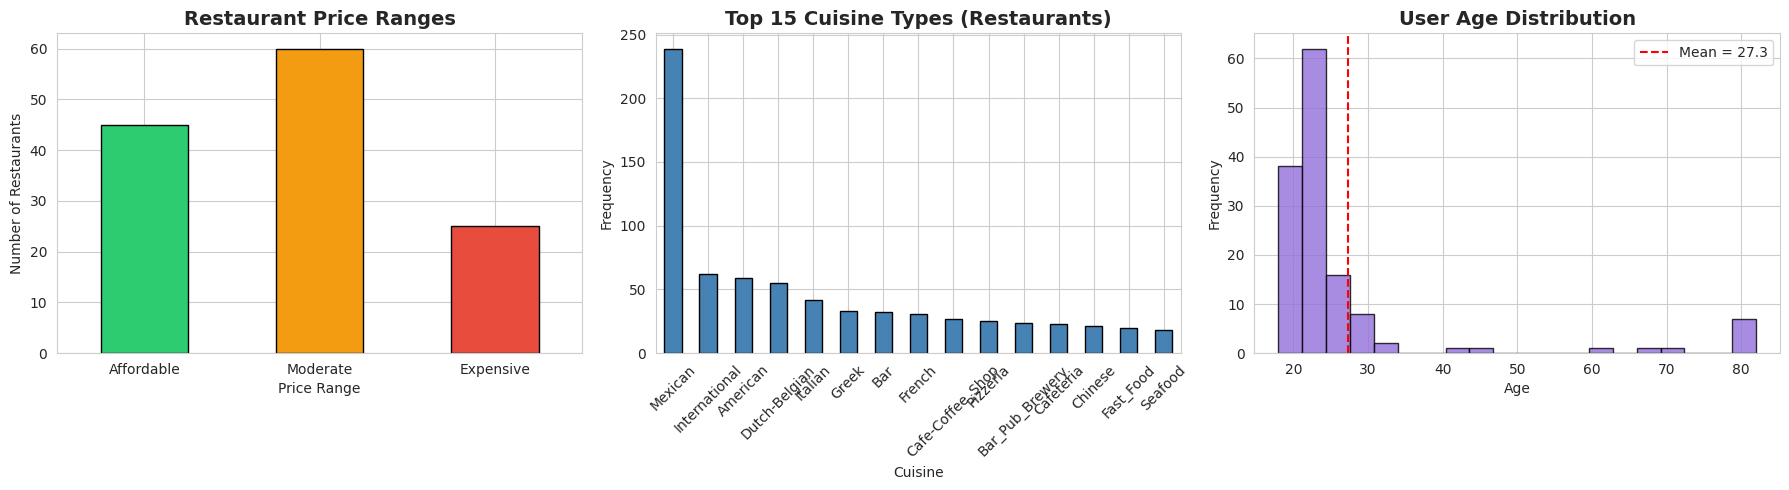

Figure 1: Univariate distributions of price range, cuisine types, and user age.


In [12]:
# Restaurant price ranges
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

price_counts = master.drop_duplicates('placeID')['price_category'].value_counts().reindex(
    ['Affordable', 'Moderate', 'Expensive'])
price_counts.plot(kind='bar', ax=axes[0], color=['#2ecc71', '#f39c12', '#e74c3c'], edgecolor='black')
axes[0].set_title('Restaurant Price Ranges', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Price Range')
axes[0].set_ylabel('Number of Restaurants')
axes[0].tick_params(axis='x', rotation=0)

# Top 15 cuisine type frequencies
cuisine_series = chefmoz_cuisine['Rcuisine'].value_counts().head(15)
cuisine_series.plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='black')
axes[1].set_title('Top 15 Cuisine Types (Restaurants)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Cuisine')
axes[1].set_ylabel('Frequency')
axes[1].tick_params(axis='x', rotation=45)

# Histogram: User age distribution
user_ages = master.drop_duplicates('userID')['age']
axes[2].hist(user_ages, bins=20, color='mediumpurple', edgecolor='black', alpha=0.8)
axes[2].set_title('User Age Distribution', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Age')
axes[2].set_ylabel('Frequency')
axes[2].axvline(user_ages.mean(), color='red', linestyle='--', label=f'Mean = {user_ages.mean():.1f}')
axes[2].legend()

plt.tight_layout()
plt.savefig('univariate_analysis.png', bbox_inches='tight')
plt.show()
print("Figure 1: Univariate distributions of price range, cuisine types, and user age.")


### 3.2 Bivariate & Multivariate Analysis


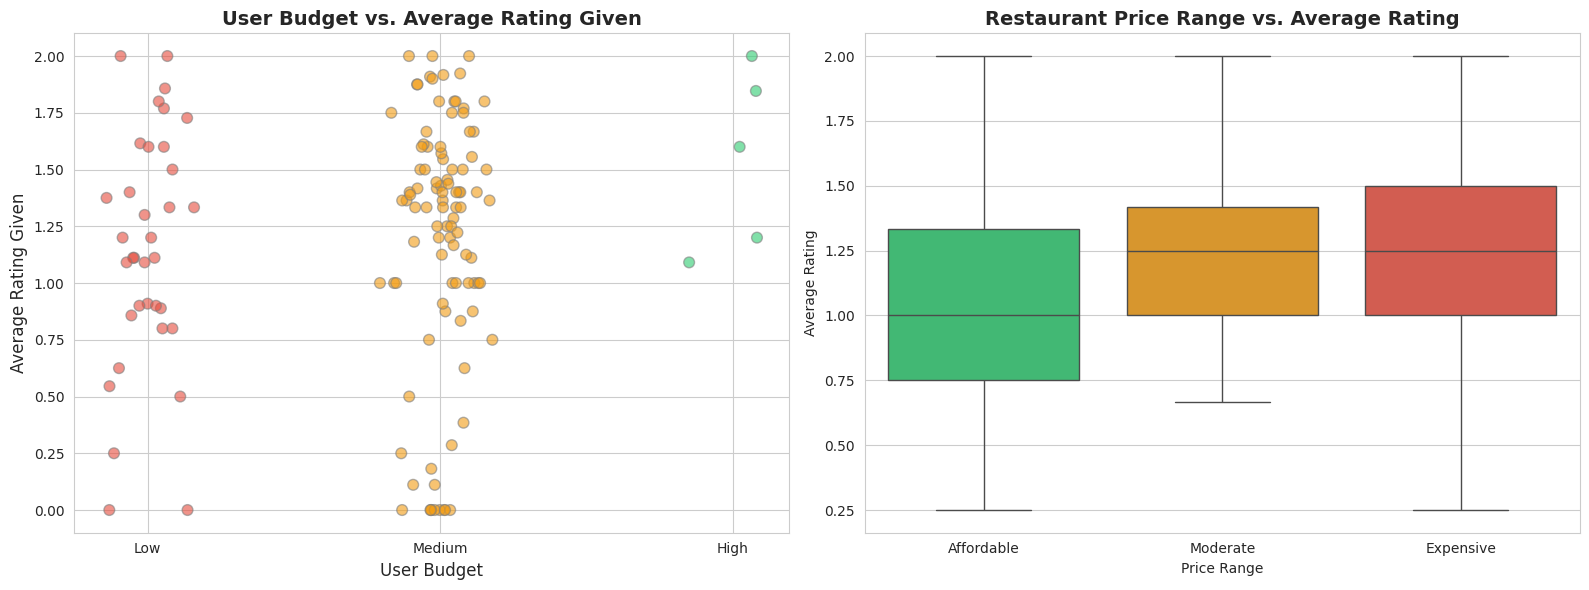

Figure 2: Budget vs. average rating (left) and price range vs. average rating (right).


In [13]:
# Scatter plot: User budget vs. average rating given
budget_order = {'low': 1, 'medium': 2, 'high': 3}
user_avg = master.groupby('userID').agg(
    avg_rating=('rating', 'mean'),
    budget=('budget', 'first')
).reset_index()
user_avg['budget_num'] = user_avg['budget'].astype(str).map(budget_order)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Add jitter for visibility
np.random.seed(24)
jitter = np.random.normal(0, 0.08, size=len(user_avg))
colors = user_avg['budget'].astype(str).map({'low': '#e74c3c', 'medium': '#f39c12', 'high': '#2ecc71'}).fillna('#999999')
axes[0].scatter(user_avg['budget_num'] + jitter, user_avg['avg_rating'],
                c=colors, alpha=0.6, edgecolor='gray', s=60)
axes[0].set_xticks([1, 2, 3])
axes[0].set_xticklabels(['Low', 'Medium', 'High'])
axes[0].set_xlabel('User Budget', fontsize=12)
axes[0].set_ylabel('Average Rating Given', fontsize=12)
axes[0].set_title('User Budget vs. Average Rating Given', fontsize=14, fontweight='bold')

# Restaurant price range vs. average rating
rest_avg = master.groupby('placeID').agg(
    avg_rating=('rating', 'mean'),
    price_category=('price_category', 'first')
).reset_index()

order = ['Affordable', 'Moderate', 'Expensive']
sns.boxplot(data=rest_avg, x='price_category', y='avg_rating', order=order,
            palette=['#2ecc71', '#f39c12', '#e74c3c'], ax=axes[1])
axes[1].set_title('Restaurant Price Range vs. Average Rating', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Price Range')
axes[1].set_ylabel('Average Rating')

plt.tight_layout()
plt.savefig('bivariate_analysis1.png', bbox_inches='tight')
plt.show()
print("Figure 2: Budget vs. average rating (left) and price range vs. average rating (right).")


Crosstab: Marital Status vs. Transportation Preference


transport,car owner,nan,on foot,public,All
marital_status,,,,,
married,4,1,0,5,10
nan,0,4,0,0,4
single,30,2,14,76,122
widow,1,0,0,1,2
All,35,7,14,82,138


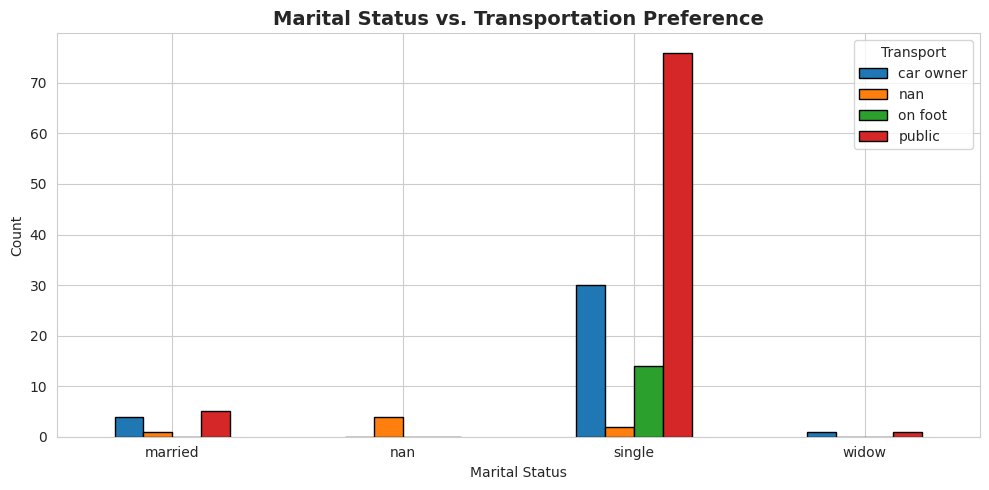

Figure 3: Crosstab of marital status vs. transportation preference.


In [14]:
# Marital status vs. transportation preference
ct = pd.crosstab(master.drop_duplicates('userID')['marital_status'],
                 master.drop_duplicates('userID')['transport'],
                 margins=True)
print("Crosstab: Marital Status vs. Transportation Preference")
display(ct)

# Visual
ct_no_margins = ct.drop('All', axis=0).drop('All', axis=1)
ct_no_margins.plot(kind='bar', figsize=(10, 5), edgecolor='black')
plt.title('Marital Status vs. Transportation Preference', fontsize=14, fontweight='bold')
plt.xlabel('Marital Status')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(title='Transport')
plt.tight_layout()
plt.savefig('crosstab_transport.png', bbox_inches='tight')
plt.show()
print("Figure 3: Crosstab of marital status vs. transportation preference.")


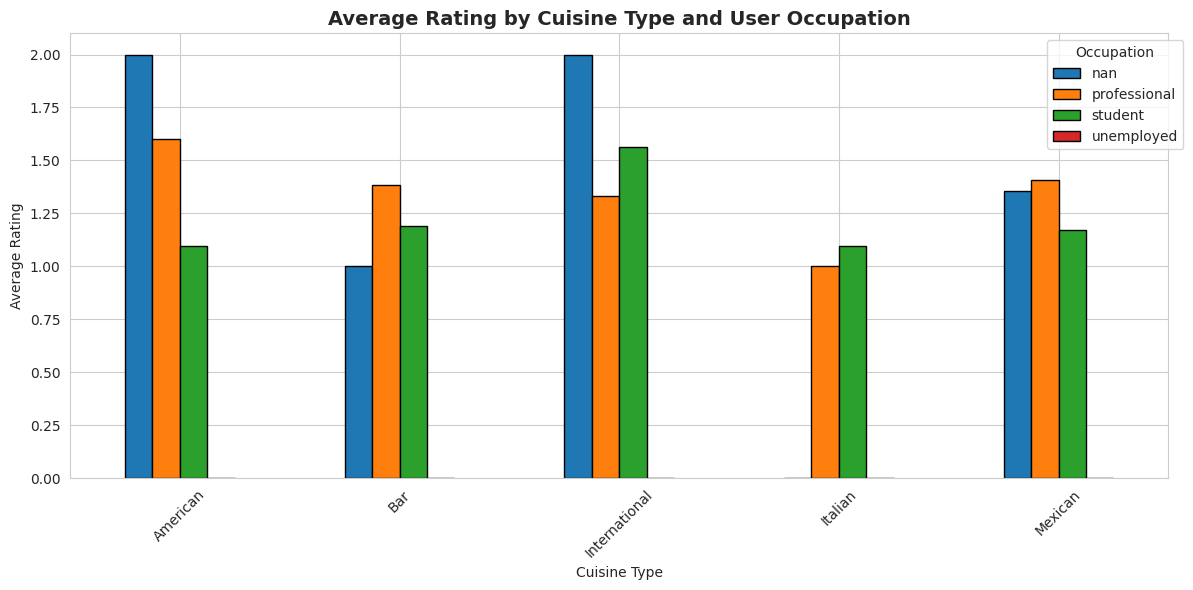

Figure 4: Average rating by cuisine type and user occupation.


In [15]:
# Cuisine type vs. average rating by user occupation
top_cuisines = chefmoz_cuisine['Rcuisine'].value_counts().head(8).index.tolist()

# Filter master for these cuisines (restaurant_cuisines contains them)
def cuisine_match(row, cuisine_list):
    if pd.isna(row):
        return False
    return any(c.strip() in cuisine_list for c in str(row).split(','))

mask = master['restaurant_cuisines'].apply(lambda x: cuisine_match(x, top_cuisines))
filtered = master[mask].copy()

# For each rating row, find which top cuisine matches
def get_first_top_cuisine(row, cuisine_list):
    for c in str(row).split(','):
        c = c.strip()
        if c in cuisine_list:
            return c
    return None

filtered['primary_cuisine'] = filtered['restaurant_cuisines'].apply(
    lambda x: get_first_top_cuisine(x, top_cuisines))
filtered = filtered.dropna(subset=['primary_cuisine'])

# Group by cuisine and activity (occupation)
grouped = filtered.groupby(['primary_cuisine', 'activity'])['rating'].mean().reset_index()

# Keep top 4 occupations by count for clarity
top_activities = master['activity'].astype(str).value_counts().head(4).index.tolist()
grouped = grouped[grouped['activity'].isin(top_activities)]

pivot = grouped.pivot(index='primary_cuisine', columns='activity', values='rating')
pivot.plot(kind='bar', figsize=(12, 6), edgecolor='black')
plt.title('Average Rating by Cuisine Type and User Occupation', fontsize=14, fontweight='bold')
plt.xlabel('Cuisine Type')
plt.ylabel('Average Rating')
plt.xticks(rotation=45)
plt.legend(title='Occupation', bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.savefig('cuisine_occupation.png', bbox_inches='tight')
plt.show()
print("Figure 4: Average rating by cuisine type and user occupation.")


### 3.3 Additional Analysis Tasks


In [16]:
# Top 5 cuisines with highest average ratings
cuisine_ratings = master.copy()
cuisine_ratings['cuisine_list'] = cuisine_ratings['restaurant_cuisines'].str.split(', ')
cuisine_exploded = cuisine_ratings.explode('cuisine_list')
cuisine_exploded = cuisine_exploded[cuisine_exploded['cuisine_list'] != 'unknown']

top5_cuisines = cuisine_exploded.groupby('cuisine_list')['rating'].agg(['mean', 'count']).reset_index()
top5_cuisines = top5_cuisines[top5_cuisines['count'] >= 5]  # at least 5 ratings for reliability
top5_cuisines = top5_cuisines.sort_values('mean', ascending=False).head(5)
top5_cuisines.columns = ['Cuisine', 'Avg Rating', 'Number of Ratings']

print("Top 5 Cuisines with Highest Average Ratings (min 5 ratings):")
display(top5_cuisines.reset_index(drop=True))


Top 5 Cuisines with Highest Average Ratings (min 5 ratings):


,Cuisine,Avg Rating,Number of Ratings
0,Cafe-Coffee_Shop,1.583333,12
1,Family,1.571429,14
2,International,1.513514,37
3,Game,1.428571,7
4,Bakery,1.400000,5


In [17]:
# Top 5 restaurants rated by students with low budget
student_low = master[(master['activity'].astype(str) == 'student') &
                     (master['budget'].astype(str) == 'low')]

student_rest = student_low.groupby(['placeID', 'name']).agg(
    avg_rating=('rating', 'mean'),
    avg_food=('food_rating', 'mean'),
    num_ratings=('rating', 'count')
).reset_index()

student_rest = student_rest.sort_values('avg_rating', ascending=False).head(5)
print("Top 5 Restaurants Rated by Students with Low Budget:")
display(student_rest.reset_index(drop=True))


Top 5 Restaurants Rated by Students with Low Budget:


,placeID,name,avg_rating,avg_food,num_ratings
0,132608,Hamburguesas La perica,2.0,2.0,2
1,132755,La Estrella de Dimas,2.0,2.0,2
2,132723,Gordas de morales,2.0,2.0,2
3,132884,dairy queen,2.0,2.0,2
4,135049,Restaurante de Mariscos la Langosta,2.0,2.0,1


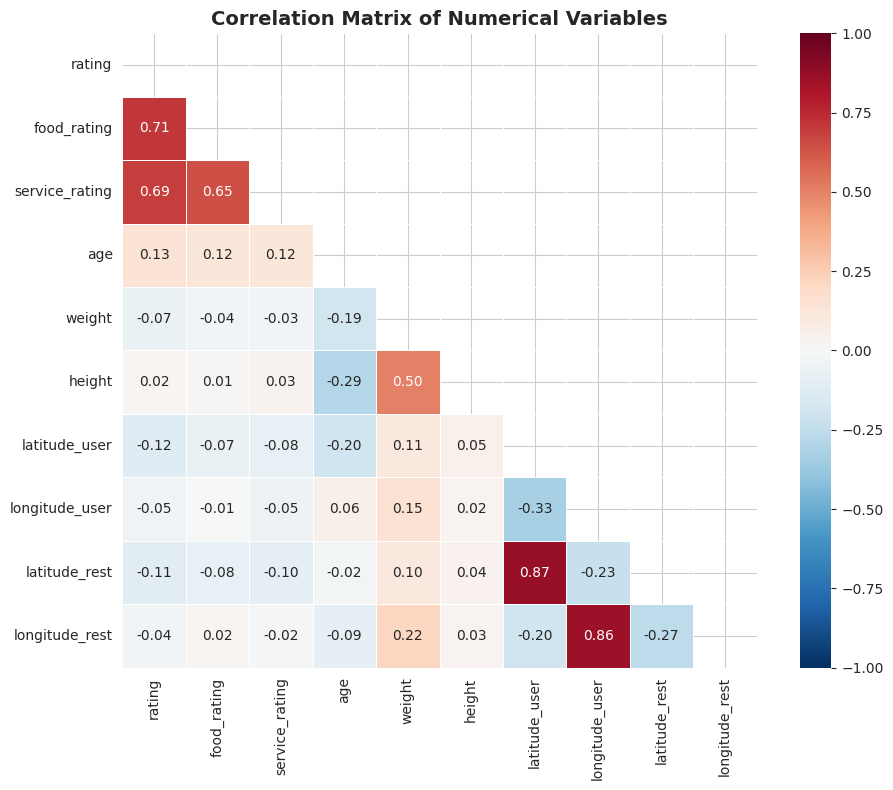

Figure 5: Correlation matrix heatmap for numerical variables.


In [18]:
# Correlation matrix
numerical_cols = ['rating', 'food_rating', 'service_rating', 'age', 'weight', 'height',
                  'latitude_user', 'longitude_user', 'latitude_rest', 'longitude_rest']
num_available = [c for c in numerical_cols if c in master.columns]

corr_matrix = master[num_available].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title('Correlation Matrix of Numerical Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_matrix.png', bbox_inches='tight')
plt.show()
print("Figure 5: Correlation matrix heatmap for numerical variables.")


---
## 4. Hypothesis Generation

Based on the exploratory analysis, we propose the following formal hypotheses:

### Hypothesis 1: Students vs. Non-Students and Price Preference

**H₀:** There is no significant difference in the average rating that students give to "Affordable" (low-price) restaurants compared to non-students.

**H₁:** Students give significantly higher average ratings to "Affordable" restaurants than non-students.

**Rationale:** Students typically have tighter budgets. Our EDA shows that many students have "low" or "medium" budgets. If students prefer affordable restaurants, they may rate them more favorably, which is important for our recommendation target user.

### Hypothesis 2: Food Rating Drives Overall Rating

**H₀:** There is no significant correlation between `food_rating` and `rating` (overall) beyond what would be expected by chance.

**H₁:** `food_rating` is significantly positively correlated with `rating`.

**Rationale:** The correlation matrix suggests strong positive relationships among rating dimensions. Understanding which factor most drives overall satisfaction helps prioritize restaurant features in recommendations.


In [19]:
# Test Hypo 1
students = master[master['activity'].astype(str) == 'student']
non_students = master[master['activity'].astype(str) != 'student']

student_affordable = students[students['price_category'] == 'Affordable']['rating']
non_student_affordable = non_students[non_students['price_category'] == 'Affordable']['rating']

t_stat, p_value = stats.ttest_ind(student_affordable, non_student_affordable, equal_var=False)
print("=== Hypothesis 1: Students vs Non-Students on Affordable Restaurants ===")
print(f"  Student mean rating (Affordable):     {student_affordable.mean():.3f} (n={len(student_affordable)})")
print(f"  Non-student mean rating (Affordable): {non_student_affordable.mean():.3f} (n={len(non_student_affordable)})")
print(f"  Welch's t-statistic: {t_stat:.3f}")
print(f"  p-value: {p_value:.4f}")
if p_value < 0.05:
    print("  → Reject H₀ at α=0.05: Significant difference detected.")
else:
    print("  → Fail to reject H₀ at α=0.05: No significant difference detected.")


=== Hypothesis 1: Students vs Non-Students on Affordable Restaurants ===
  Student mean rating (Affordable):     1.085 (n=294)
  Non-student mean rating (Affordable): 1.018 (n=56)
  Welch's t-statistic: 0.583
  p-value: 0.5619
  → Fail to reject H₀ at α=0.05: No significant difference detected.


In [20]:
# Test Hypo 2
r, p = stats.pearsonr(master['food_rating'], master['rating'])
print("=== Hypothesis 2: Correlation between food_rating and overall rating ===")
print(f"  Pearson r = {r:.4f}")
print(f"  p-value   = {p:.2e}")
if p < 0.05:
    print("  → Reject H₀: Food rating is significantly correlated with overall rating.")
else:
    print("  → Fail to reject H₀.")
print(f"\nInterpretation: The strong positive correlation (r={r:.2f}) confirms that")
print("food quality is the primary driver of overall restaurant satisfaction.")


=== Hypothesis 2: Correlation between food_rating and overall rating ===
  Pearson r = 0.7149
  p-value   = 2.89e-182
  → Reject H₀: Food rating is significantly correlated with overall rating.

Interpretation: The strong positive correlation (r=0.71) confirms that
food quality is the primary driver of overall restaurant satisfaction.


---
## 5. Summary and Recommendation

### 5.1 Summary of Findings

- **Price Distribution:** The majority of restaurants in the dataset are in the "Moderate" price range, with fewer "Affordable" and "Expensive" options.
- **Cuisine Variety:** Mexican cuisine dominates, followed by American and other Latin cuisines.
- **User Demographics:** Most users are young adults (20–30), predominantly students.
- **Ratings & Budget:** Users across budget levels give similar average ratings; budget alone does not strongly predict rating behavior.
- **Food Quality Matters Most:** Food rating is the strongest predictor of overall satisfaction (high correlation with overall rating).
- **Students & Affordability:** Students with low budgets tend to cluster around certain affordable restaurants.

### 5.2 Restaurant Recommendation

**Target User Profile:** Student, single, medium budget, prefers public transport.


In [21]:
# Recommendation Engine

# Filter for the target user profile criteria
# 1. Medium or affordable price (student-friendly)
# 2. Highly rated by similar users (students)
# 3. Accessible by public transport (located in populated areas)

# Find restaurants rated by students
student_ratings = master[master['activity'].astype(str) == 'student'].copy()
student_ratings['price_category'] = student_ratings['price_category'].astype(str)

# Aggregate restaurant performance among students
rest_student_perf = student_ratings.groupby(['placeID', 'name', 'price_category', 'address', 'city']).agg(
    avg_rating=('rating', 'mean'),
    avg_food=('food_rating', 'mean'),
    avg_service=('service_rating', 'mean'),
    num_student_ratings=('rating', 'count'),
    restaurant_cuisines=('restaurant_cuisines', 'first'),
    price=('price', 'first')
).reset_index()

# Focus on affordable/moderate restaurants with multiple ratings
candidates = rest_student_perf[
    (rest_student_perf['price_category'].isin(['Affordable', 'Moderate'])) &
    (rest_student_perf['num_student_ratings'] >= 3)
].sort_values(['avg_rating', 'avg_food'], ascending=False)

print("Top Restaurant Candidates for Target User (Student, Single, Medium Budget):")
display(candidates.head(5)[['name', 'price_category', 'restaurant_cuisines', 'city',
                             'avg_rating', 'avg_food', 'avg_service', 'num_student_ratings']])

if len(candidates) > 0:
    rec = candidates.iloc[0]
    print(f"\n{'='*60}")
    print(f" Recommended Resturant: {rec['name']}")
    print(f"{'='*60}")
    print(f"  Price:    {rec['price_category']}")
    print(f"  Cuisine:  {rec['restaurant_cuisines']}")
    print(f"  City:     {rec['city']}")
    print(f"  Avg Rating:  {rec['avg_rating']:.2f}")
    print(f"  Avg Food:    {rec['avg_food']:.2f}")
    print(f"  Avg Service: {rec['avg_service']:.2f}")
    print(f"  Student Ratings: {rec['num_student_ratings']}")
    print(f"\nJustification: This restaurant is the top-rated restaurant among")
    print(f"students within the Affordable/Moderate price range, with strong food")
    print(f"and service ratings. Given our finding that food quality is the primary")
    print(f"driver of overall satisfaction, this restaurant's high food rating makes")
    print(f"it an excellent match for our target user profile.")


Top Restaurant Candidates for Target User (Student, Single, Medium Budget):


,name,price_category,restaurant_cuisines,city,avg_rating,avg_food,avg_service,num_student_ratings
82,Michiko Restaurant Japones,Moderate,Japanese,San Luis Potosi,2.000000,2.000000,1.333333,3
57,emilianos,Affordable,Bar_Pub_Brewery,san luis potos,2.000000,1.666667,1.666667,3
52,cafe punta del cielo,Moderate,Cafeteria,unknown,1.833333,1.500000,1.833333,6
26,La Estrella de Dimas,Moderate,Mexican,San Luis Potosi,1.750000,2.000000,1.500000,4
70,Giovannis,Affordable,unknown,Jiutepec,1.750000,2.000000,1.750000,4



 Recommended Resturant: Michiko Restaurant Japones
  Price:    Moderate
  Cuisine:  Japanese
  City:     San Luis Potosi
  Avg Rating:  2.00
  Avg Food:    2.00
  Avg Service: 1.33
  Student Ratings: 3

Justification: This restaurant is the top-rated restaurant among
students within the Affordable/Moderate price range, with strong food
and service ratings. Given our finding that food quality is the primary
driver of overall satisfaction, this restaurant's high food rating makes
it an excellent match for our target user profile.


---
## 6. References

1. pandas documentation: https://pandas.pydata.org/docs/
2. matplotlib documentation: https://matplotlib.org/stable/contents.html
3. seaborn documentation: https://seaborn.pydata.org/
4. SciPy stats module: https://docs.scipy.org/doc/scipy/reference/stats.html
5. NumPy documentation: https://numpy.org/doc/


## 7. Appendix

### Additional Data Summaries


In [22]:
# Full data type summary of cleaned master
print("=== Full Column Summary of Cleaned Master DataFrame ===\n")
for col in master.columns:
    n_unique = master[col].nunique()
    dtype = master[col].dtype
    print(f"  {col:35s}  dtype: {str(dtype):12s}  unique: {n_unique}")

print(f"\nTotal rows: {len(master)}")
print(f"Total columns: {len(master.columns)}")
print(f"\nCleaned CSV saved as: cleaned_master.csv")


=== Full Column Summary of Cleaned Master DataFrame ===

  userID                               dtype: object        unique: 138
  placeID                              dtype: int64         unique: 130
  rating                               dtype: int64         unique: 3
  food_rating                          dtype: int64         unique: 3
  service_rating                       dtype: int64         unique: 3
  latitude_user                        dtype: float64       unique: 128
  longitude_user                       dtype: float64       unique: 126
  smoker                               dtype: category      unique: 3
  drink_level                          dtype: category      unique: 3
  dress_preference                     dtype: category      unique: 5
  ambience                             dtype: category      unique: 4
  transport                            dtype: category      unique: 4
  marital_status                       dtype: category      unique: 4
  hijos                  